In [1]:
# -*- coding: utf-8 -*-
"""
Created on September 17, 2019
Revised on April 01, 2025

@author:       Oscar Trevizo (adapted from Anjum and Adebisi at Kaggle)
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Naive Bayes — Kaggle Social Network Ads
========================================

Description:
    Demonstrates binary classification using scikit-learn GaussianNB
    on the Kaggle Social Network Ads dataset. Loads data, selects features
    Age and EstimatedSalary (dropping User ID and Gender), scales with
    StandardScaler, fits a Gaussian Naive Bayes classifier, evaluates
    with a confusion matrix, and visualizes decision boundaries for
    training and test sets.

    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)
    Features used:   Age, EstimatedSalary
    Features dropped: User ID (identifier), Gender (categorical, not encoded)

    Key sklearn API used:
        - StandardScaler.fit_transform() / transform()
        - GaussianNB.fit() / predict()
        - sklearn.metrics.confusion_matrix()

Data:
    ../data/Social_Network_Ads.csv

References:
    1. Social Network Ads - Naive Bayes by Anjum at Kaggle
       https://www.kaggle.com/code/areeshaary/social-network-ads-naive-bayes
    2. Naive Bayes Classifier on Social Media Ads by Adebisi at Kaggle
       https://www.kaggle.com/code/olusesiadebisi/naive-bayes-classifier-on-social-media-ads

Revision History:
    2019-09-17  Original copied from Kaggle as a learning tool
                - Added comments for deeper understanding

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Confirmed: GaussianNB API unchanged (no max_iter, closed-form solver)
                - Fixed: replaced hardcoded iloc positional indices with
                  explicit column names (Age, EstimatedSalary, Purchased)
                - Fixed: removed dead sklearn.cross_validation comment
                  (module removed in sklearn 0.20; active import already correct)
                - Fixed: replaced ListedColormap callable pattern with
                  list indexing to avoid TypeError in matplotlib >= 3.7
"""


'\nCreated on September 17, 2019\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo (adapted from Anjum and Adebisi at Kaggle)\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nNaive Bayes — Kaggle Social Network Ads\n========================================\n\nDescription:\n    Demonstrates binary classification using scikit-learn GaussianNB\n    on the Kaggle Social Network Ads dataset. Loads data, selects features\n    Age and EstimatedSalary (dropping User ID and Gender), scales with\n    StandardScaler, fits a Gaussian Naive Bayes classifier, evaluates\n    with a confusion matrix, and visualizes decision boundaries for\n    training and test sets.\n\n    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)\n    Features used:   Age, EstimatedSalary\n    Features dropped: User ID (iden

# Libraries

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data

In [3]:
# Importing the dataset
# Columns: User ID, Gender, Age, EstimatedSalary, Purchased
# Features: Age and EstimatedSalary (drop User ID and Gender)
# Target:   Purchased (binary: 0 = no purchase, 1 = purchase)
dataset = pd.read_csv('../data/Social_Network_Ads.csv')
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values


# Split train test datasets

In [4]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


# Transform to scale the data

In [5]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Fit the model

In [6]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


# Predict

In [7]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Evaluate the model

In [8]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 7 25]]


# Visualize results

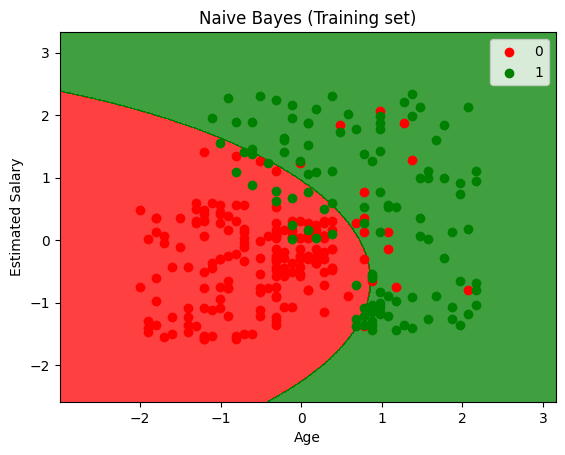

In [9]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

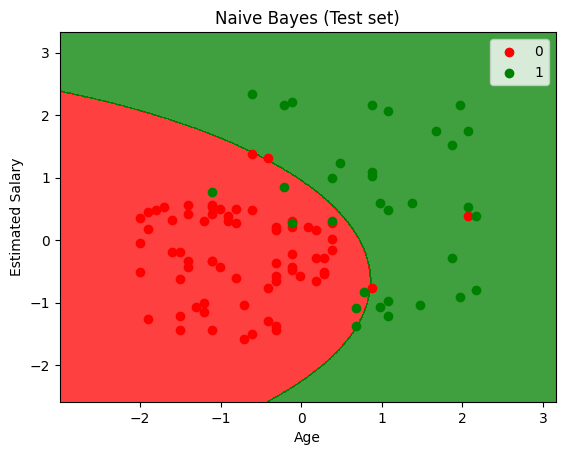

In [10]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()